<a href="https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/Transformer_translate_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer로 번역기 만들기 [프로젝트]

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

In [ ]:
import os
import unicodedata
from pathlib import Path
import torch

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def select_device():
    # Colab의 CUDA GPU를 먼저, Apple Silicon에서는 MPS를 사용합니다.
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def resolve_work_dir():
    custom = os.environ.get("TRANSFORMER_HOME")
    if IN_COLAB:
        drive.mount("/content/drive")
        drive_root = Path("/content/drive/MyDrive")
        if not drive_root.is_dir():
            raise RuntimeError("Google Drive 연결을 확인하고 이 셀을 다시 실행하세요.")
        return Path(custom).expanduser() if custom else drive_root / "Aiffel_EPA/transformer"
    if custom:
        return Path(custom).expanduser()

    # Google Drive for desktop의 영문/한글 폴더 이름을 함께 찾습니다.
    roots = [child for account in (Path.home() / "Library/CloudStorage").glob("GoogleDrive-*")
             for child in account.iterdir()
             if unicodedata.normalize("NFC", child.name) in {"My Drive", "내 드라이브"}
             and child.is_dir()]
    if len(roots) == 1:
        return roots[0] / "Aiffel_EPA/transformer"
    if len(roots) > 1:
        raise RuntimeError("Drive 계정이 여러 개입니다. TRANSFORMER_HOME에 사용할 전체 경로를 지정하세요.")
    print("Google Drive 동기화 폴더가 없어 로컬 폴더에 저장합니다.")
    return Path.home() / "Aiffel_EPA/transformer"


device = select_device()
WORK_DIR = resolve_work_dir()
DATA_DIR = WORK_DIR / "data"
MODEL_DIR = WORK_DIR / "models"
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
for directory in (DATA_DIR, MODEL_DIR, CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print("실행 장치:", device)
print("데이터 저장·로드:", DATA_DIR)
print("체크포인트:", CHECKPOINT_DIR)


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'

# Colab에서는 기존 Nanum 폰트를, Mac에서는 설치된 Apple 한글 폰트를 사용합니다.
fontpath = Path('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
if IN_COLAB and not fontpath.exists():
    import subprocess
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], check=True)
if not fontpath.exists():
    fontpath = Path('/System/Library/Fonts/AppleSDGothicNeo.ttc')
if fontpath.exists():
    fm.fontManager.addfont(str(fontpath))
    plt.rc('font', family=fm.FontProperties(fname=str(fontpath)).get_name())
plt.rc('axes', unicode_minus=False)
print("슝=3")

## 5. 프로젝트: 더 멋진 번역기 만들기

## 라이브러리 버전을 확인해 봅니다.
---
사용할 라이브러리 버전을 둘러봅시다.

In [ ]:
import torch
import numpy
import matplotlib

print(torch.__version__)
print(numpy.__version__)
print(matplotlib.__version__)

2.11.0+cu128
2.1.3
3.10.0

## Step 1. 데이터 다운로드
---
아래 링크에서 `korean-english-park.train.tar.gz` 를 다운로드받아 한영 병렬 데이터를 확보합니다.

  - [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)

데이터는 준비 셀의 Google Drive 경로에 저장합니다. 다음 셀은 저장된 한국어·영어 파일을 재사용하고, 누락된 파일만 압축파일에서 복원합니다. 아래 터미널 예시는 Colab 경로를 설명하는 참고용이며, 실제 실행은 다음 Python 셀을 사용합니다.

```
$ mkdir -p /content/drive/MyDrive/Aiffel_EPA/transformer/data
$ cd /content/drive/MyDrive/Aiffel_EPA/transformer/data
$ wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
$ tar -xzvf korean-english-park.train.tar.gz
```

In [ ]:
import shutil
import tarfile
import tempfile
import urllib.request

DATA_URL = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"


def prepare_parallel_data(data_dir):
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)
    names = ["korean-english-park.train.ko", "korean-english-park.train.en"]
    missing = [name for name in names if not (data_dir / name).is_file()]
    if not missing:
        print("저장된 한국어·영어 데이터를 다시 사용합니다.")
        return

    archive_path = data_dir / "korean-english-park.train.tar.gz"
    if not archive_path.exists():
        # 다운로드가 끝나고 archive 형식이 확인된 파일만 최종 이름으로 옮깁니다.
        with tempfile.TemporaryDirectory(dir=data_dir) as temporary:
            downloaded = Path(temporary) / archive_path.name
            urllib.request.urlretrieve(DATA_URL, downloaded)
            with tarfile.open(downloaded, "r:gz") as archive:
                available = {Path(member.name).name for member in archive.getmembers() if member.isfile()}
                if not set(names).issubset(available):
                    raise ValueError("압축파일에서 필요한 한국어·영어 파일을 찾지 못했습니다.")
            os.replace(downloaded, archive_path)

    with tarfile.open(archive_path, "r:gz") as archive:
        members = {Path(member.name).name: member for member in archive.getmembers() if member.isfile()}
        for name in missing:
            # 이미 있는 언어 파일은 보존하고, 누락된 파일만 복원합니다.
            with tempfile.TemporaryDirectory(dir=data_dir) as temporary:
                restored = Path(temporary) / name
                with archive.extractfile(members[name]) as source, restored.open("wb") as target:
                    shutil.copyfileobj(source, target)
                os.replace(restored, data_dir / name)
    print("데이터 준비 완료:", data_dir)


prepare_parallel_data(DATA_DIR)


## Step 2. 데이터 정제 및 토큰화
---

- 1️⃣ `set` 데이터형이 **중복을 허용하지 않는다는 것을 활용**해 중복된 데이터를 제거하도록 합니다. 데이터의 **병렬 쌍이 흐트러지지 않게 주의**하세요! 중복을 제거한 데이터를 `cleaned_corpus` 에 저장합니다.

In [ ]:
kor_path = os.path.join(DATA_DIR, "korean-english-park.train.ko")
eng_path = os.path.join(DATA_DIR, "korean-english-park.train.en")

def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r", encoding="utf-8") as f:
        kor = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f:
        eng = f.read().splitlines()
    assert len(kor) == len(eng), "한국어·영어 문장 수가 다릅니다"

    # (한국어, 영어) 쌍을 하나의 튜플로 묶어 set 에 넣으면 쌍 단위로 중복이 제거됩니다.
    # dict.fromkeys 는 set 과 같은 중복 제거를 하면서 원래 순서를 유지합니다.
    cleaned_corpus = list(dict.fromkeys(zip(kor, eng)))

    print(f"원본 문장 쌍: {len(kor):,}  →  중복 제거 후: {len(cleaned_corpus):,}")
    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)
print(cleaned_corpus[0])

원본 문장 쌍: 94,123  →  중복 제거 후: 78,968
('개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"', 'Much of personal computing is about "can you top this?"')

- 2️⃣ 정제 함수를 아래 조건을 만족하게 정의합니다.

> - 모든 입력을 소문자로 변환합니다.
> - 알파벳, 문장부호, 한글만 남기고 모두 제거합니다.
> - 문장부호 양옆에 공백을 추가합니다.
> - 문장 앞뒤의 불필요한 공백을 제거합니다.

In [ ]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()                                # 1. 모든 입력을 소문자로
    sentence = re.sub(r"[^a-z가-힣?.!,]+", " ", sentence)     # 2. 알파벳·한글·문장부호(?.!,) 만 남기고 나머지는 공백으로
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)          # 3. 문장부호 양옆에 공백
    sentence = re.sub(r"\s+", " ", sentence)                   #    연속 공백을 하나로
    return sentence.strip()                                    # 4. 문장 앞뒤 공백 제거

print(preprocess_sentence("Obama, the 44th President,  said: \"Yes we can!\""))
print(preprocess_sentence("  일곱 명의 사망자가 발생했다.  "))

obama , the th president , said yes we can !
일곱 명의 사망자가 발생했다 .

- 3️⃣ 한글 말뭉치 `kor_corpus` 와 영문 말뭉치 `eng_corpus` 를 각각 분리한 후, 정제하여 토큰화를 진행합니다! 토큰화에는 Sentencepiece를 활용하세요. 첨부된 공식 사이트를 참고해 아래 조건을 만족하는 `generate_tokenizer()` 함수를 정의합니다. 최종적으로 `ko_tokenizer` 과 `en_tokenizer` 를 얻으세요. 영문(타겟) 문장을 인코딩할 때는 `add_bos=True, add_eos=True` 를 주어 문장의 시작 토큰과 끝 토큰이 포함되게 합니다. (다음 단계 4️⃣ 에서 실제로 적용합니다.)

  - [google/sentencepiece](https://github.com/google/sentencepiece)

> - 단어 사전을 매개변수로 받아 원하는 크기의 사전을 정의할 수 있게 합니다. (기본: 20,000)
> - 학습 후 저장된 **`model`** 파일을 **`SentencePieceProcessor()`** 클래스에 **`Load()`**한 후 반환합니다.
> - 특수 토큰의 인덱스를 아래와 동일하게 지정합니다. **`<PAD>`** : 0 / **`<BOS>`** : 1 / **`<EOS>`** : 2 / **`<UNK>`** : 3

In [ ]:
import sentencepiece as spm


def generate_tokenizer(corpus, vocab_size, lang="ko",
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    model_path = MODEL_DIR / f"{lang}_spm.model"
    legacy_path = DATA_DIR / f"{lang}_spm.model"
    saved_path = model_path if model_path.exists() else legacy_path
    tokenizer = spm.SentencePieceProcessor()
    if saved_path.exists():
        tokenizer.Load(str(saved_path))
        actual_ids = (tokenizer.pad_id(), tokenizer.bos_id(), tokenizer.eos_id(), tokenizer.unk_id())
        if tokenizer.vocab_size() != vocab_size or actual_ids != (pad_id, bos_id, eos_id, unk_id):
            raise ValueError(f"{saved_path}의 단어장 크기 또는 특수 token ID가 설정과 다릅니다.")
        print("저장된 토크나이저 로드:", saved_path)
        return tokenizer

    # 처음 실행할 때만 학습하고, 완성된 model/vocab 파일을 Drive에 보관합니다.
    with tempfile.TemporaryDirectory(dir=MODEL_DIR) as temporary:
        corpus_path = Path(temporary) / f"{lang}_corpus.txt"
        model_prefix = Path(temporary) / f"{lang}_spm"
        corpus_path.write_text("\n".join(corpus) + "\n", encoding="utf-8")
        spm.SentencePieceTrainer.train(
            input=str(corpus_path), model_prefix=str(model_prefix), vocab_size=vocab_size,
            pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id)
        tokenizer.Load(str(model_prefix) + ".model")
        for suffix in (".vocab", ".model"):
            os.replace(str(model_prefix) + suffix, MODEL_DIR / f"{lang}_spm{suffix}")
    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

kor_corpus = []
eng_corpus = []
for k, e in cleaned_corpus:
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")

print("PAD/BOS/EOS/UNK:", en_tokenizer.pad_id(), en_tokenizer.bos_id(), en_tokenizer.eos_id(), en_tokenizer.unk_id())
print(ko_tokenizer.encode_as_pieces(kor_corpus[0]))
# 영어 입력과 정답을 한 칸씩 옮길 수 있도록 시작·종료 토큰을 붙입니다.
print(en_tokenizer.encode_as_ids(eng_corpus[0], add_bos=True, add_eos=True))


- 4️⃣ 토크나이저를 활용해 **토큰의 길이가 50 이하**인 데이터를 선별하여 `src_corpus` 와 `tgt_corpus` 를 각각 구축하고, 텐서 `enc_train` 과 `dec_train` 으로 변환합니다! (❗모든 데이터를 사용할 경우 학습에 굉장히 오랜 시간이 걸립니다.)

In [ ]:
from tqdm.notebook import tqdm  # 진행 과정 보기

src_corpus = []
tgt_corpus = []

assert len(kor_corpus) == len(eng_corpus)

# 토큰의 길이가 50 이하인 문장만 남깁니다. 타겟(영문)에는 <BOS>·<EOS> 를 붙입니다.
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx], add_bos=True, add_eos=True)

    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

# 패딩처리를 완료하여 학습용 데이터를 완성합니다.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

print(f"사용 문장 쌍: {len(src_corpus):,} / {len(kor_corpus):,}")
print(enc_train.shape, dec_train.shape)
print(dec_train[0])   # 1 로 시작하고 2 뒤에 0(<PAD>) 이 이어져야 함

  0%|          | 0/78968 [00:00<?, ?it/s]

사용 문장 쌍: 75,567 / 78,968
torch.Size([75567, 50]) torch.Size([75567, 50])
tensor([   1,  282,    8, 1237, 8799,   17,   47,   95,   93,  210,   42,   77,
           3,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])

## Step 3. 모델 설계
---
오늘 배운 내용을 활용해서 `Transformer` 모델을 설계합니다!

## Step 4. 훈련하기
---
앞서 "모델 설계"에서 필요한 것들을 모두 정의했다면 우리는 훈련만 하면 됩니다! 아래 과정을 차근차근 따라가며 모델을 훈련하고, **예문에 대한 멋진 번역**을 제출하세요!

- 1️⃣ **2 Layer**를 가지는 `Transformer`를 선언합니다. \
(하이퍼파라미터는 자유롭게 조절합니다.)

In [ ]:
# 기존 모델 설정값을 그대로 유지하며 checkpoint에서도 일치 여부를 확인합니다.
MODEL_CONFIG = dict(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True,
)
transformer = Transformer(**MODEL_CONFIG).to(device)

- 2️⃣ 논문에서 사용한 것과 동일한 **Learning Rate Scheduler**를 선언하고, 이를 포함하는 **Adam Optimizer**를 선언합니다.\
(Optimizer의 파라미터 역시 논문과 동일하게 설정합니다.)

In [ ]:
optimizer = optim.Adam(transformer.parameters(), lr=1.0,
                       betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer,
                                        lr_lambda=noam_schedule(d_model=512,
                                                                warmup_steps=4000))

n_params = sum(p.numel() for p in transformer.parameters())
print(f"파라미터 수: {n_params:,}")

파라미터 수: 35,213,856

- 3️⃣ **Loss 함수를 정의**합니다.\
Sequence-to-sequence 에서 썼던 것과 같이 `CrossEntropyLoss(ignore_index=0)` 으로 `<PAD>` 위치를 loss 에서 제외합니다. 트랜스포머는 모든 위치의 출력을 한 번에 내므로 `[batch, length, vocab]` 을 `[batch×length, vocab]` 으로 펼쳐 넘겨야 합니다. `ignore_index` 는 제외한 토큰을 분모에서도 빼기 때문에, "마스킹되지 않은 토큰 수로 나눈 평균" 이 자동으로 됩니다.

In [ ]:
loss_object = torch.nn.CrossEntropyLoss(ignore_index=0)   # <PAD>=0 은 loss 계산과 평균의 분모에서 모두 제외

def loss_function(real, pred):
    """
    real : 정답 토큰 id      [batch, tgt_len]
    pred : 모델 출력 logits  [batch, tgt_len, vocab_size]
    """
    return loss_object(pred.reshape(-1, pred.size(-1)),   # [batch*tgt_len, vocab_size]
                       real.reshape(-1))                  # [batch*tgt_len]

- 4️⃣ `train_step` 함수를 정의합니다.\
**입력 데이터에 알맞은 Mask를 생성**하고, 이를 모델에 전달하여 연산에서 사용할 수 있게 합니다.

In [ ]:
def train_step(src, tgt, model, optimizer, scheduler):
    model.train()
    src, tgt = src.to(device), tgt.to(device)

    # 디코더 입력은 <BOS> w1 w2 … , 정답은 w1 w2 … <EOS>  (한 칸 어긋나게)
    dec_in = tgt[:, :-1]
    gold   = tgt[:, 1:]

    # 입력 데이터에 알맞은 Mask 생성
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_in)

    # 계산된 loss 에 대해 역전파(Backpropagation)를 적용해 학습을 진행합니다.
    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, dec_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions)
    loss.backward()

    optimizer.step()
    scheduler.step()          # 논문의 lr 스케줄은 step 단위로 갱신

    return loss.item(), enc_attns, dec_attns, dec_enc_attns

- 5️⃣ **학습을 진행**합니다.\
**매 Epoch 마다 제시된 예문에 대한 번역을 생성**하고, 멋진 번역이 생성되면 그때의 **하이퍼파라미터와 생성된 번역을 제출**하세요!

예문

```
1. 오바마는 대통령이다.
2. 시민들은 도시 속에 산다.
3. 커피는 필요 없다.
4. 일곱 명의 사망자가 발생했다.
```

결과(output)

```
Translations
> 1. obama is the president elect .
> 2. they are in the city .
> 3. they don t need to be a lot of drink .
> 4. seven other people have been killed in the attacks .

Hyperparameters
> n_layers: 2
> d_model: 512
> n_heads: 8
> d_ff: 2048
> dropout: 0.3

Training Parameters
> Warmup Steps: 4000
> Batch Size: 64
> Epoch At: 5
```

번역 생성에는 아래 소스를 사용하시길 바랍니다!

In [ ]:
# Attention 시각화 함수

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns, n_heads=4):
    """
    src / tgt      : 축 라벨로 쓸 토큰 조각 리스트 (소스 조각, <BOS> + 생성 조각)
    enc_attns 등   : 층별 어텐션 가중치 리스트, 각 원소 [batch, heads, q_len, k_len]
    n_heads        : 한 줄에 그릴 head 수 (모델 head 수 이하)
    """
    def draw(data, ax, x="auto", y="auto"):
        seaborn.heatmap(data.detach().cpu().numpy(),     # grad 분리 → CPU → numpy
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    for layer in range(len(enc_attns)):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(n_heads):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    for layer in range(len(dec_attns)):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        print("Decoder Self Layer", layer + 1)
        for h in range(n_heads):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer + 1)
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        for h in range(n_heads):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

In [ ]:
# 번역 생성 함수

def evaluate(sentence, model, src_tokenizer, tgt_tokenizer, max_len=None):
    model.eval()                                            # dropout 끄기
    max_len = max_len or dec_train.shape[-1]                # 기본: 학습 데이터의 최대 길이

    sentence = preprocess_sentence(sentence)
    # 시각화 축 라벨용 조각. SentencePiece 의 단어 경계 기호 '▁'(U+2581) 는 나눔 폰트에 없어 제거
    pieces = [p.replace('▁', '') for p in src_tokenizer.encode_as_pieces(sentence)]
    tokens = src_tokenizer.encode_as_ids(sentence)
    _input = torch.tensor(tokens, device=device).unsqueeze(0)          # [1, src_len]

    ids = []
    output = torch.tensor([[tgt_tokenizer.bos_id()]], device=device)   # [1, 1] — <BOS> 로 시작

    with torch.no_grad():                                   # 추론에는 그래프가 필요 없음
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output)
            predictions, enc_attns, dec_attns, dec_enc_attns = \
                model(_input, output, enc_mask, dec_enc_mask, dec_mask)

            predicted_id = predictions[0, -1].argmax().item()   # 마지막 위치의 최댓값 = 다음 토큰

            if predicted_id == tgt_tokenizer.eos_id():
                break

            ids.append(predicted_id)
            output = torch.cat([output, torch.tensor([[predicted_id]], device=device)], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)
    tgt_pieces = ['<BOS>'] + [tgt_tokenizer.id_to_piece(i).replace('▁', '') for i in ids]   # 디코더 입력 위치와 1:1

    return pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns

In [ ]:
# 번역 생성 및 Attention 시각화 결합

def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    if plot_attention:
        visualize_attention(pieces, tgt_pieces, enc_attns, dec_attns, dec_enc_attns)

### Checkpoint(체크포인트) 저장과 이어 학습

학습 시작 직전, 100개 배치마다, 각 epoch(에포크) 끝에 `transformer_latest.pt`를 저장합니다. 다시 실행하면 모델·optimizer(최적화 도구)·학습률·다음 배치 위치를 함께 복원합니다. `EPOCHS=5`는 전체 목표 5회를 뜻하며 완료한 에포크를 반복하지 않습니다.

중단되면 마지막 저장 이후의 배치는 다시 계산합니다. 저장 도중 실패해도 이전 완성 파일을 보존합니다. 새 실험은 다른 `CHECKPOINT_PATH`를 지정하고 `RESUME_TRAINING=False`로 시작하세요. 같은 저장 경로에서는 한 번에 하나의 학습만 실행합니다. Mac↔Colab 장치를 바꾸어 재개할 수 있으며 장치가 달라지면 난수·계산 결과가 완전히 같지는 않을 수 있습니다.

In [ ]:
import tempfile

CHECKPOINT_EVERY_BATCHES = 100
RESUME_TRAINING = True
CHECKPOINT_PATH = CHECKPOINT_DIR / "transformer_latest.pt"


def _cpu_state(value):
    # 학습이 잠시 멈춘 상태에서 저장하므로 다음 업데이트와 섞이지 않습니다.
    if isinstance(value, torch.Tensor):
        return value.detach().cpu()
    if isinstance(value, dict):
        return {key: _cpu_state(item) for key, item in value.items()}
    if isinstance(value, list):
        return [_cpu_state(item) for item in value]
    if isinstance(value, tuple):
        return tuple(_cpu_state(item) for item in value)
    return value


def _atomic_torch_save(payload, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(dir=path.parent, suffix=".tmp", delete=False) as handle:
        temporary = Path(handle.name)
    try:
        torch.save(payload, temporary)
        os.replace(temporary, path)  # 저장이 끝난 파일로만 latest를 교체합니다.
    finally:
        temporary.unlink(missing_ok=True)


def save_checkpoint(epoch, next_batch, batch_order, total_loss):
    state = {
        "model": _cpu_state(transformer.state_dict()),
        "optimizer": _cpu_state(optimizer.state_dict()),
        "scheduler": scheduler.state_dict(),
        "signature": training_signature,
        "epoch": epoch,
        "next_batch": next_batch,
        "batch_order": batch_order,
        "total_loss": total_loss,
        "python_rng": random.getstate(),
        "torch_rng": torch.get_rng_state(),
        "device_type": device.type,
    }
    if device.type == "cuda":
        state["cuda_rng"] = torch.cuda.get_rng_state_all()
    elif device.type == "mps":
        state["mps_rng"] = torch.mps.get_rng_state()
    _atomic_torch_save(state, CHECKPOINT_PATH)


def load_checkpoint():
    if not RESUME_TRAINING or not CHECKPOINT_PATH.exists():
        return None
    # 이 노트북에서 저장한 tensor·기본 자료형을 CPU로 먼저 읽습니다.
    state = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
    if state["signature"] != training_signature:
        raise ValueError("체크포인트의 데이터·토크나이저·설정이 다릅니다. 새 실험은 다른 CHECKPOINT_PATH를 사용하세요.")
    transformer.load_state_dict(state["model"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    random.setstate(state["python_rng"])
    torch.set_rng_state(state["torch_rng"])
    if device.type == state.get("device_type"):
        if device.type == "cuda":
            torch.cuda.set_rng_state_all(state["cuda_rng"])
        elif device.type == "mps":
            torch.mps.set_rng_state(state["mps_rng"])
    print(f"체크포인트 로드: {state['epoch'] + 1}번째 epoch, 완료 배치 {state['next_batch']}개")
    return state


In [ ]:
# EPOCHS는 추가 실행 횟수가 아니라 전체 목표 epoch 수입니다.
from tqdm import tqdm
import hashlib

BATCH_SIZE = 64
EPOCHS = 5

examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

# 같은 token ID라도 토크나이저가 바뀌면 의미가 달라져 재개 전에 확인합니다.
training_signature = {
    "model_config": MODEL_CONFIG,
    "batch_size": BATCH_SIZE,
    "encoder_data": hashlib.sha256(enc_train.numpy().tobytes()).hexdigest(),
    "decoder_data": hashlib.sha256(dec_train.numpy().tobytes()).hexdigest(),
    "ko_tokenizer": hashlib.sha256(ko_tokenizer.serialized_model_proto()).hexdigest(),
    "en_tokenizer": hashlib.sha256(en_tokenizer.serialized_model_proto()).hexdigest(),
}
resume = load_checkpoint()
start_epoch = resume["epoch"] if resume else 0
if resume is None:
    # 첫 주기 저장 전에 중단되어도 처음 상태부터 일관되게 다시 시작합니다.
    save_checkpoint(0, 0, None, 0.0)

try:
    for epoch in range(start_epoch, EPOCHS):
        continuing = resume is not None and resume["batch_order"] is not None
        total_loss = resume["total_loss"] if continuing else 0.0
        next_batch = resume["next_batch"] if continuing else 0
        idx_list = resume["batch_order"] if continuing else list(range(0, enc_train.shape[0], BATCH_SIZE))
        if not continuing:
            random.shuffle(idx_list)
        t = tqdm(range(next_batch, len(idx_list)), initial=next_batch, total=len(idx_list))

        for batch in t:
            idx = idx_list[batch]
            batch_loss, enc_attns, dec_attns, dec_enc_attns = train_step(
                enc_train[idx:idx+BATCH_SIZE], dec_train[idx:idx+BATCH_SIZE],
                transformer, optimizer, scheduler)
            total_loss += batch_loss
            t.set_description('Epoch %2d' % (epoch + 1))
            t.set_postfix({'Loss': '%.4f' % (total_loss / (batch + 1)),
                           'lr': '%.2e' % scheduler.get_last_lr()[0]})
            if (batch + 1) % CHECKPOINT_EVERY_BATCHES == 0:
                save_checkpoint(epoch, batch + 1, idx_list, total_loss)

        # 다음 epoch부터 이어가도록 저장한 뒤 예문을 번역합니다.
        save_checkpoint(epoch + 1, 0, None, 0.0)
        resume = None
        print("체크포인트 저장:", CHECKPOINT_PATH)
        for example in examples:
            translate(example, transformer, ko_tokenizer, en_tokenizer)
except KeyboardInterrupt:
    # 중단 시점의 불완전한 업데이트 대신 마지막으로 완료된 저장본을 유지합니다.
    print("학습 중단. 마지막 저장 지점부터 재개하려면 학습 셀을 다시 실행하세요.")
    raise


## Attention Map 읽는 법
---
아래 셀은 첫 예문 `오바마는 대통령이다.` 의 번역 과정에서 만들어진 Attention 가중치를 그립니다. 2개 층 × 3종류 = 6장의 그림이 나오고, 각 그림에는 8개 head 중 앞 4개가 나란히 놓입니다. 모든 그림에서 **세로축은 Query(질문하는 쪽), 가로축은 Key(참조되는 쪽)** 이고, 한 행의 값을 모두 더하면 1 입니다. 밝을수록 그 위치를 많이 봤다는 뜻입니다.

| 그림 | 세로축 (Query) | 가로축 (Key) | 확인할 것 |
|---|---|---|---|
| **Encoder Layer** | 소스 조각 | 소스 조각 | 한국어 조각들이 서로 어떤 관계를 맺는지. 조사 `는`·`이` 가 앞 명사를 보는 식의 패턴이 보이면 좋습니다. |
| **Decoder Self Layer** | `<BOS>` + 생성 조각 | `<BOS>` + 생성 조각 | **대각선 위쪽(오른쪽 위)이 모두 어두워야 합니다.** 인과 관계 마스크가 미래 토큰을 가리고 있다는 증거입니다. 첫 행 `<BOS>` 는 자기 자신만 볼 수 있어 첫 칸만 밝습니다. |
| **Decoder Src Layer** | `<BOS>` + 생성 조각 | 소스 조각 | **이 레슨의 핵심 장면입니다.** 영어 단어 행이 대응하는 한국어 조각 열에서 밝아야 합니다. 예: `president` 행 → `대통령이` 열, `.` 행 → `.` 열. 어순이 다른 두 언어 사이에서 어텐션이 대응 관계를 스스로 찾아낸 것입니다. |

몇 가지 참고할 점입니다.

- **head 마다 그림이 다른 것이 정상입니다.** 어떤 head 는 대응 단어를 정확히 보고, 어떤 head 는 문장 끝 `.` 이나 `<BOS>` 같은 한 곳만 봅니다. 여러 head 가 서로 다른 관계를 나누어 맡는 것이 Multi-Head Attention 의 의도였죠(강의 노드 5절). 4개 중 한두 개에서라도 뚜렷한 대응이 보이면 충분합니다.
- **`obama` 행은 흐릿할 수 있습니다.** 첫 단어를 낼 때 디코더가 아는 것은 `<BOS>` 뿐이라 소스 전체를 두루 보는 경향이 있습니다. 두 번째 단어부터 대응이 선명해지는 것이 보통입니다.
- **1층과 2층은 역할이 다릅니다.** 아래층은 단어 대응처럼 국소적인 관계를, 위층은 문장 전체를 뭉뚱그려 보는 패턴을 자주 보입니다. 두 층을 비교해 보세요.
- 축 라벨은 SentencePiece 조각 단위이며, 단어 경계 기호 `▁` 는 폰트에 없어 라벨에서 제거했습니다. 한국어 조각과 영어 조각의 개수가 다른 것은 두 토크나이저가 따로 학습되었기 때문입니다.

여러분의 결과에서도 이런 대응이 보이는지 확인하고, **어느 층·어느 head 에서 어떤 단어 쌍이 연결되었는지** 를 제출물에 한두 문장으로 적어 주세요. 루브릭의 "시각화된 Attention Map 으로 결과를 뒷받침한다" 가 바로 이 부분입니다.

Input: 오바마는 대통령이다.
Predicted translation: obama is president .
Encoder Layer 1

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)

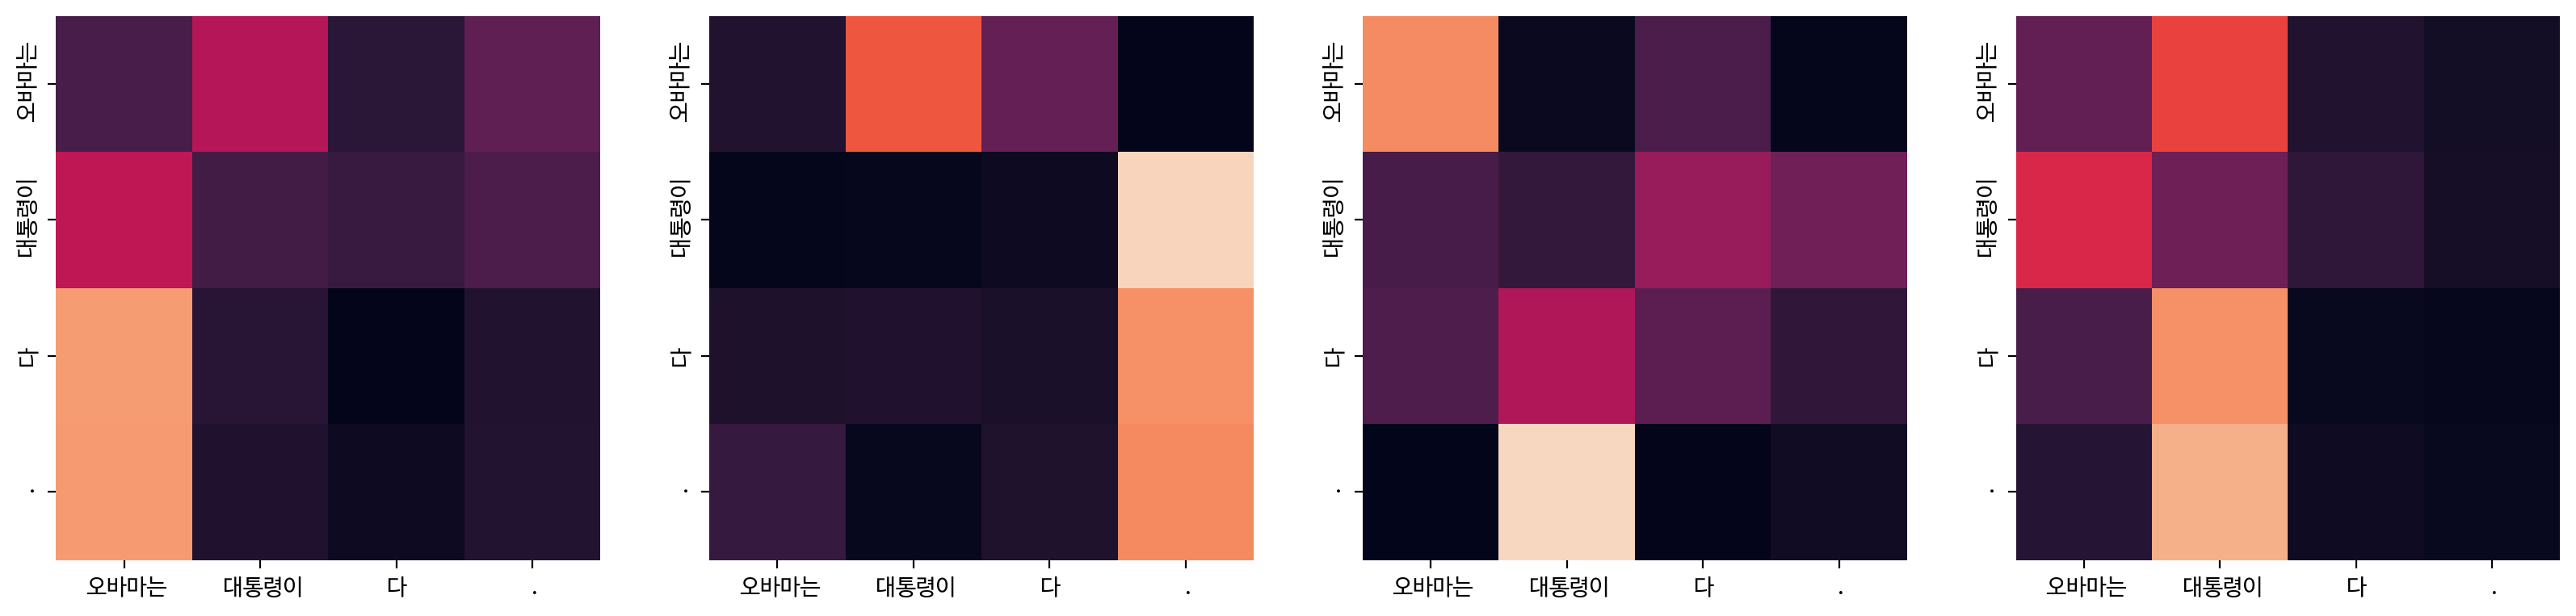

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()

Encoder Layer 2

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)

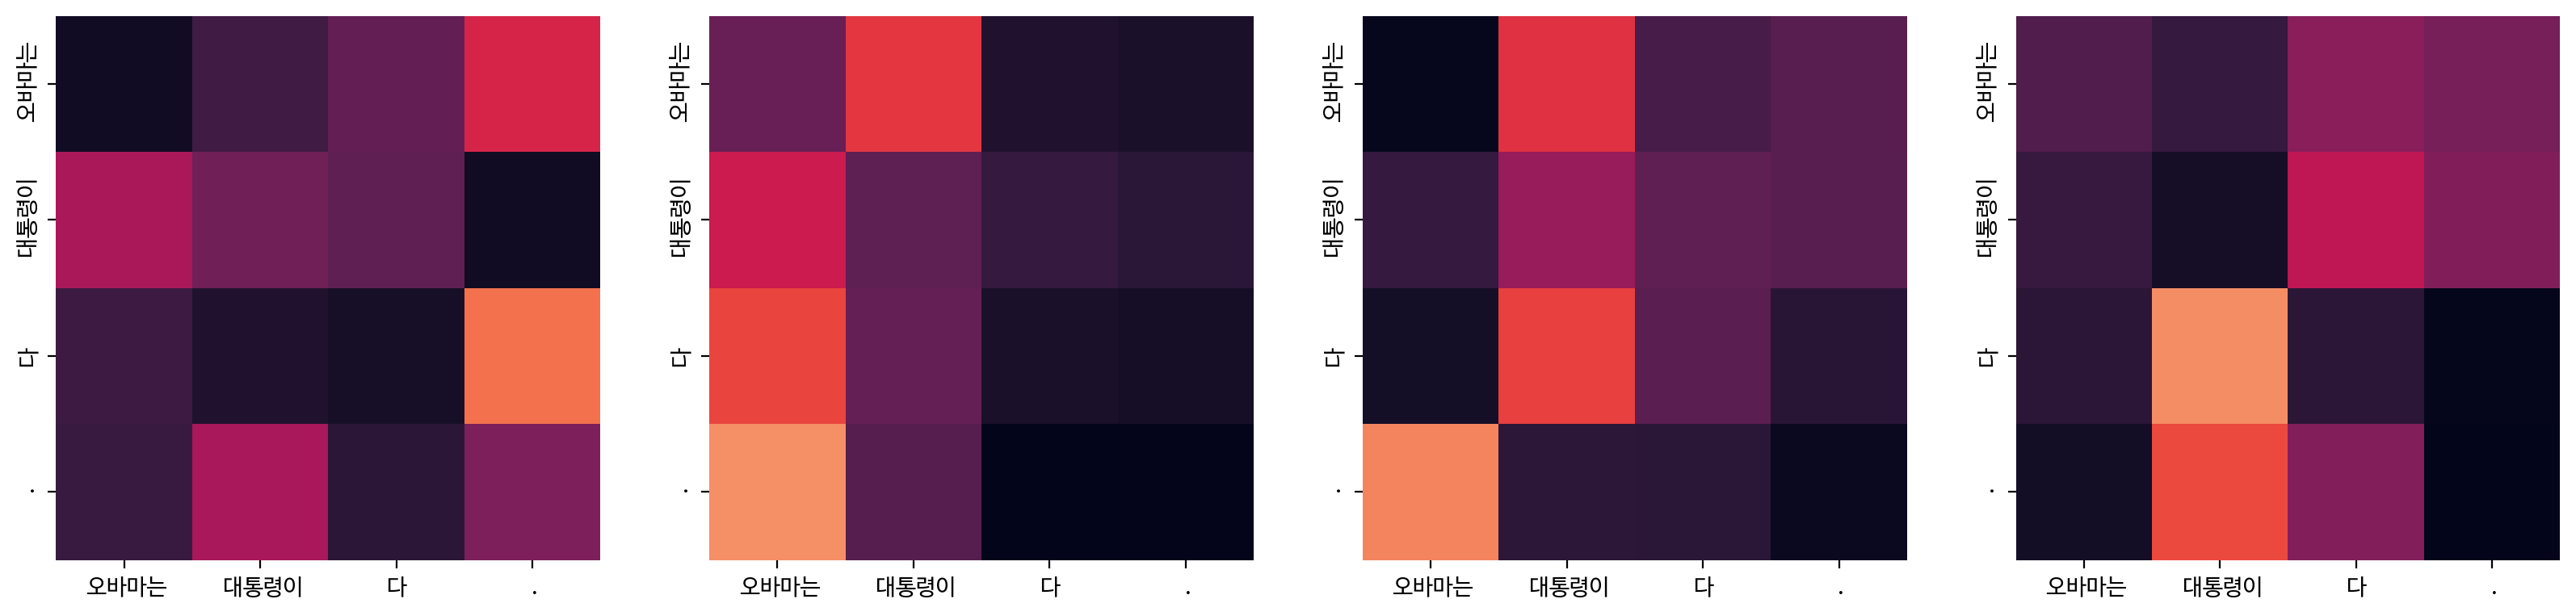

Decoder Self Layer 1

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)

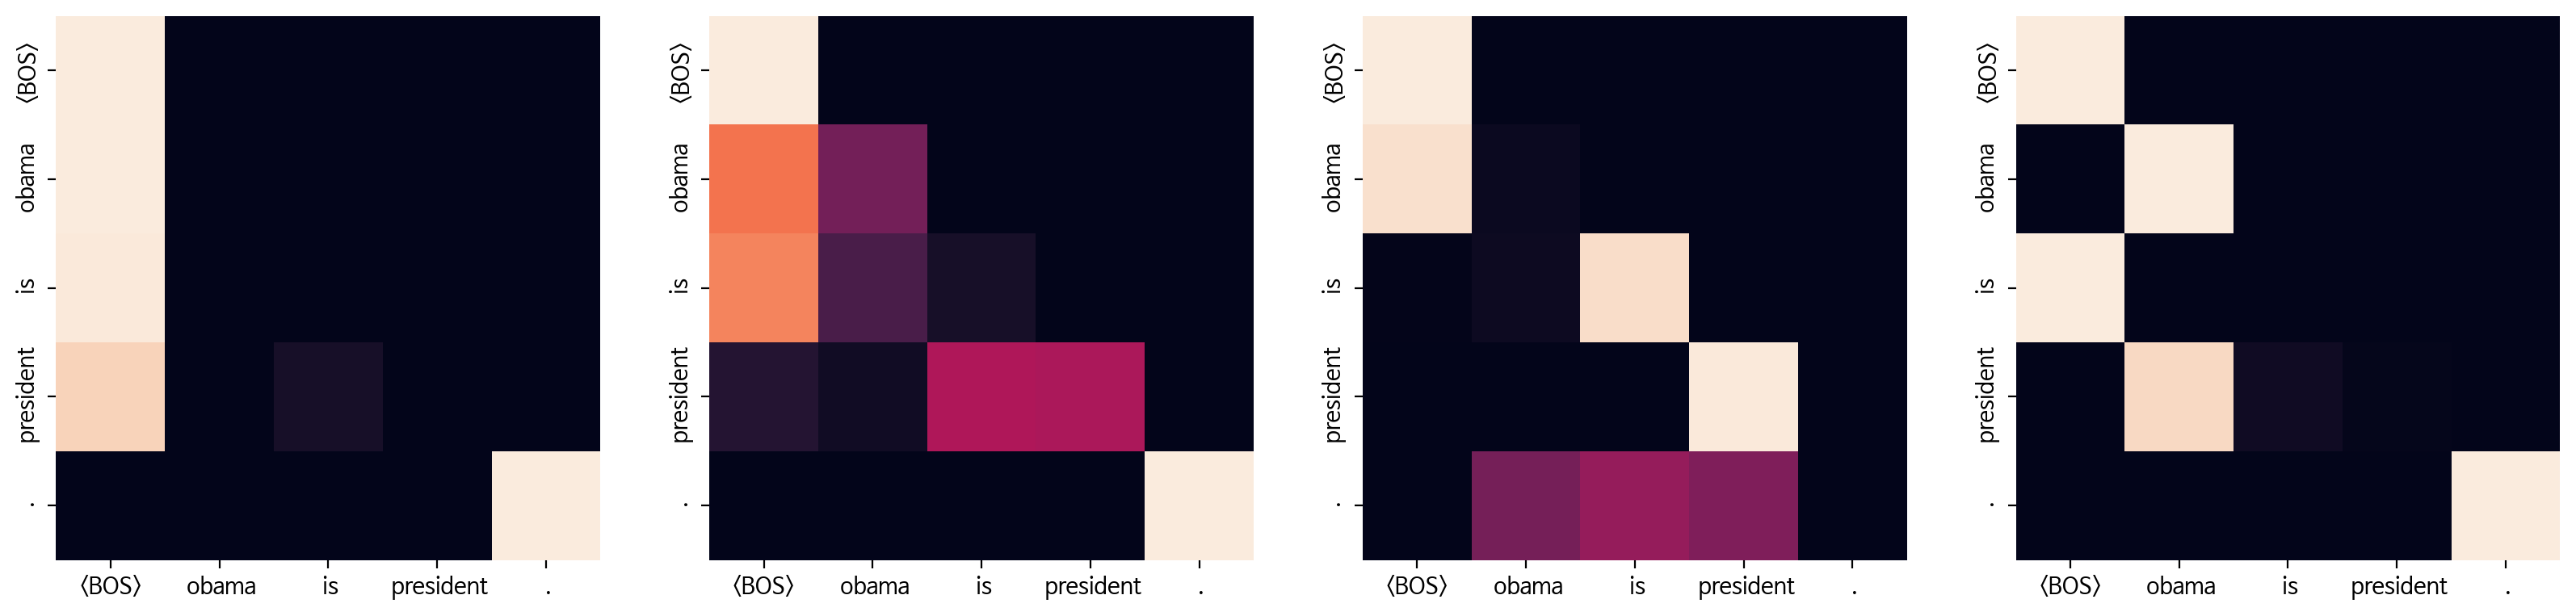

Decoder Src Layer 1

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)

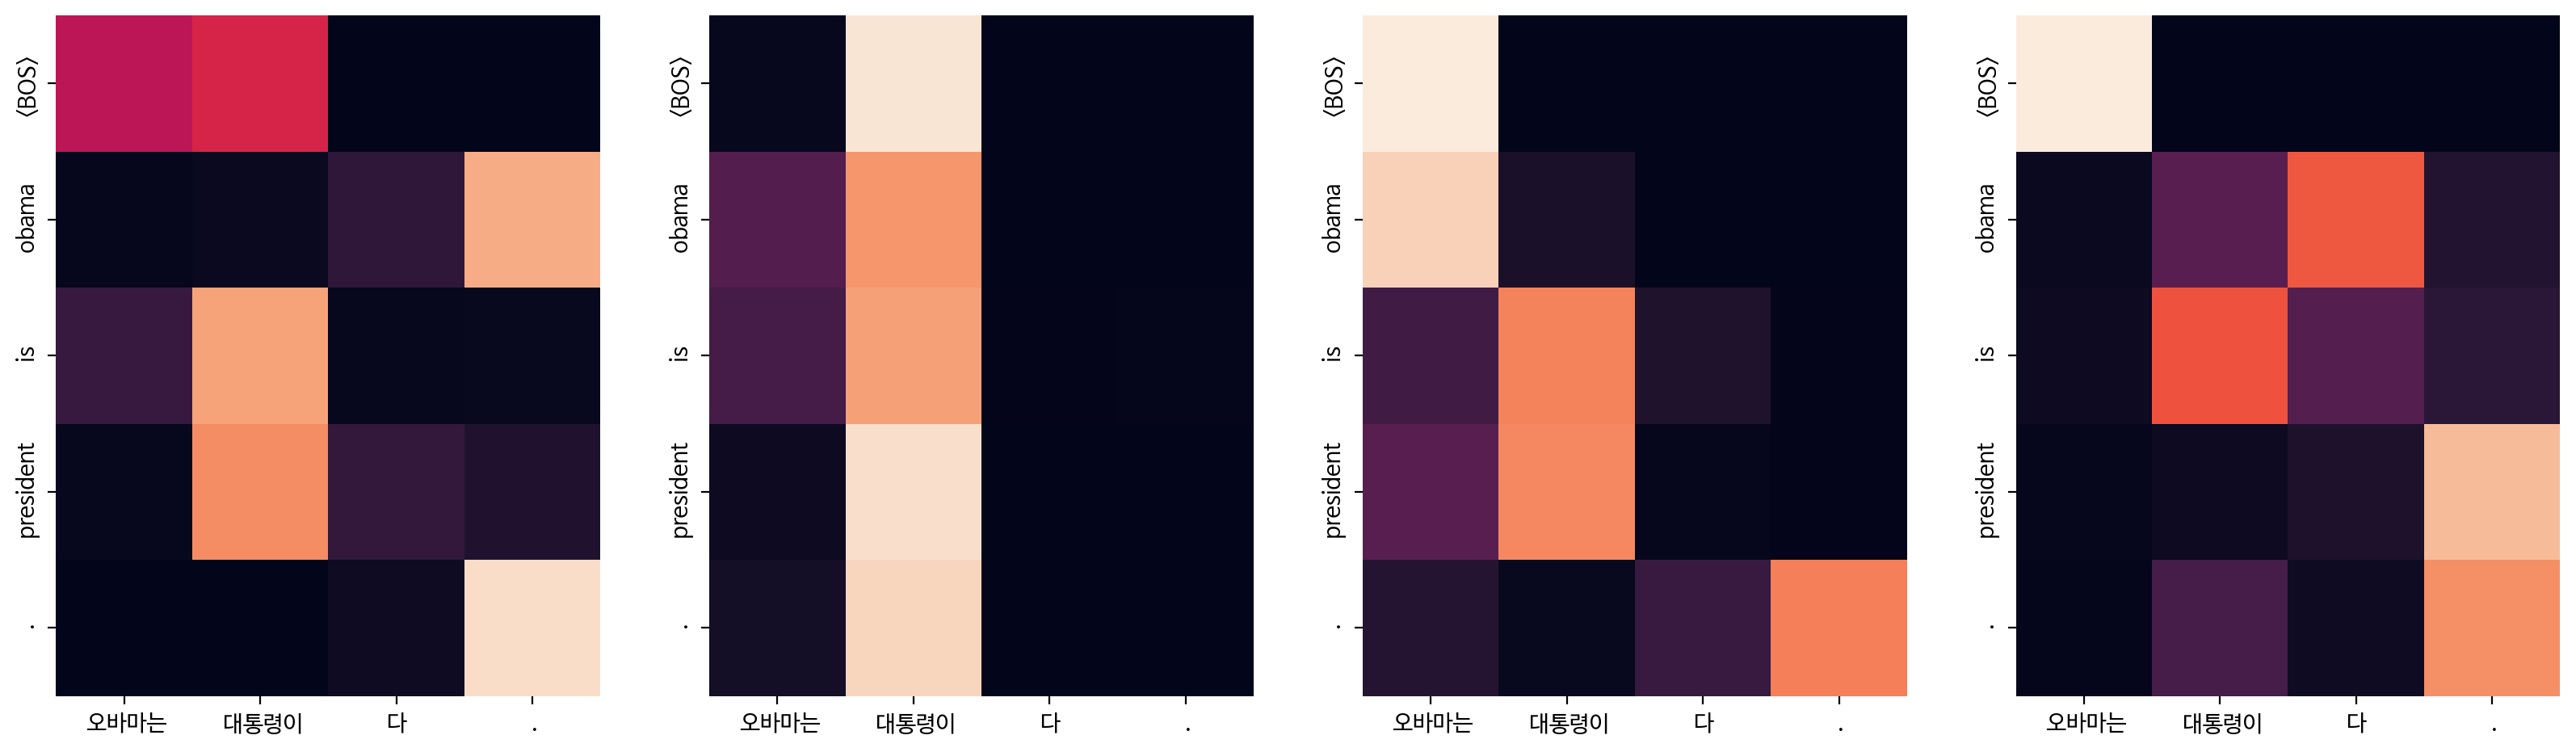

Decoder Self Layer 2

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)

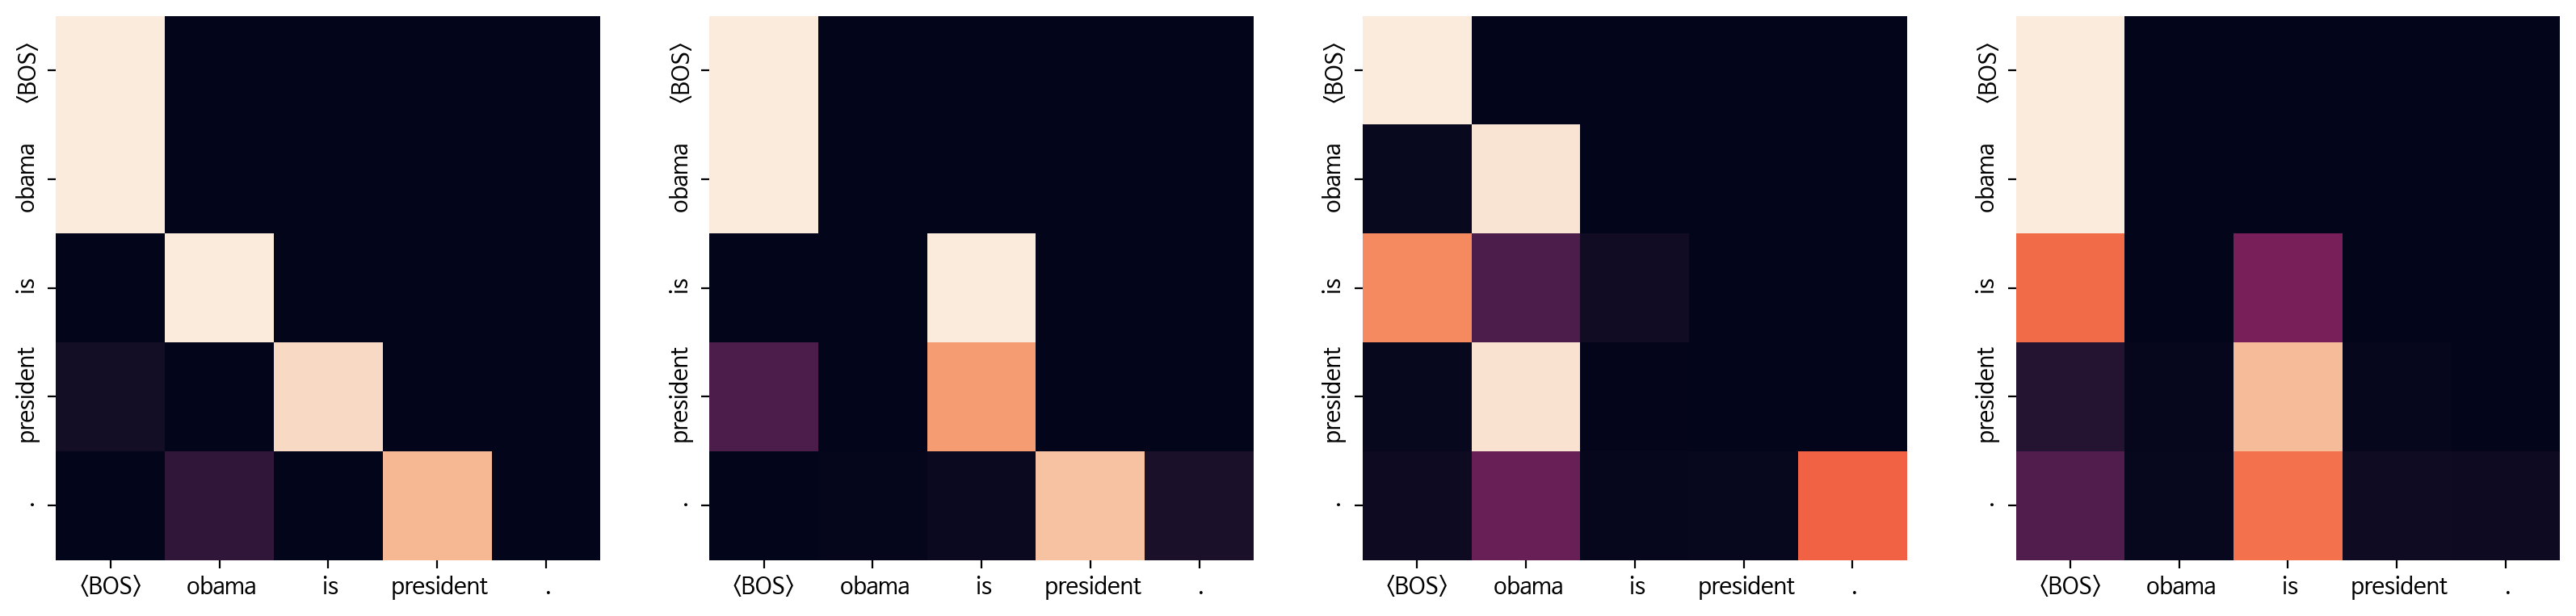

Decoder Src Layer 2

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)

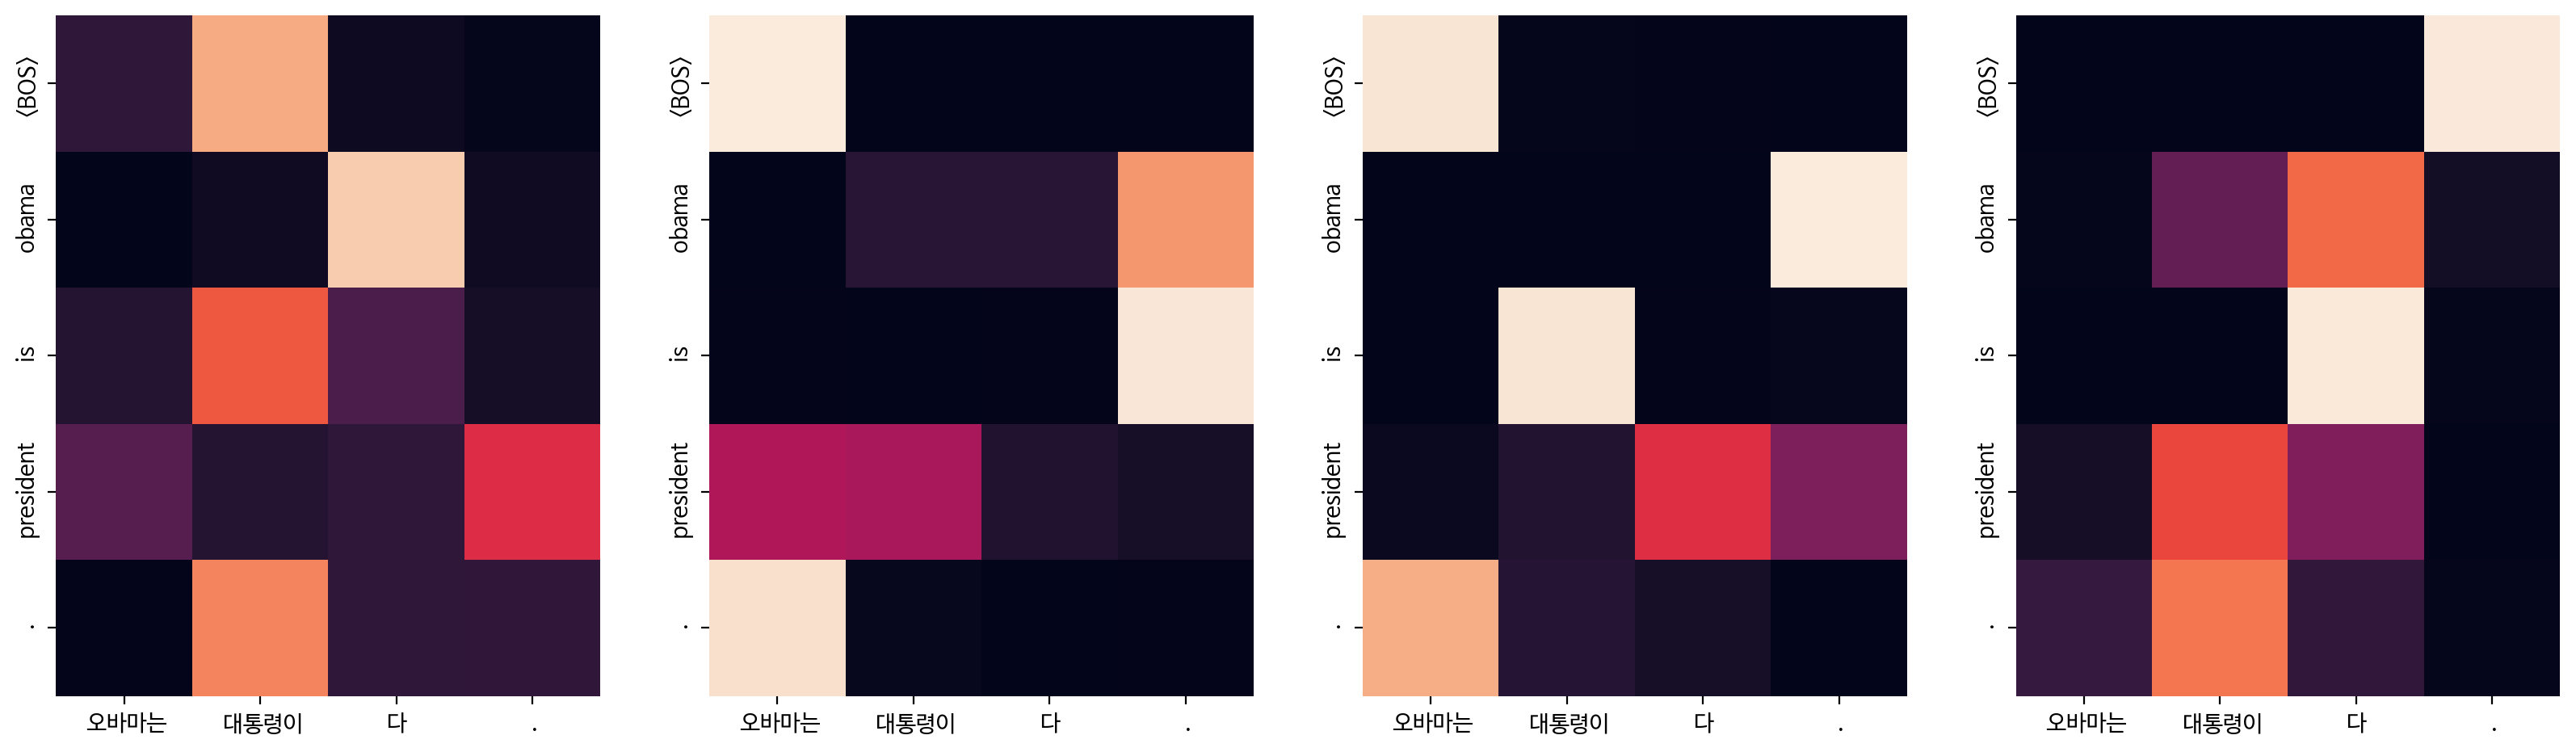

In [ ]:
# 학습이 끝난 뒤 Attention Map 확인
translate(examples[0], transformer, ko_tokenizer, en_tokenizer, plot_attention=True)

위 셀 마지막 줄처럼 `translate()` 함수의 `plot_attention` 변수를 `True` 로 주면 **번역 결과에 대한 Attention Map을 시각화** 해볼 수 있습니다. 소스 조각(가로축)과 생성된 조각(세로축)이 어디에 연결되는지 살펴보고, 어순이 다른 한→영 번역에서 어텐션이 어떻게 움직이는지 해석해 보세요.

멋진 번역이 나왔다면 그때의 **하이퍼파라미터와 생성된 번역, Attention Map 해석**을 정리해 제출하세요. 수고하셨습니다!!

## 프로젝트 제출

## 루브릭

- 번역기 모델 학습에 필요한 텍스트 데이터 전처리가 잘 이루어졌다.
    - 데이터 정제, SentencePiece를 활용한 토큰화 및 데이터셋 구축의 과정이 지시대로 진행되었다.
- Transformer 번역기 모델이 정상적으로 구동된다.
    - Transformer 모델의 학습과 추론 과정이 정상적으로 진행되어, 한-영 번역기능이 정상 동작한다.
- 테스트 결과 의미가 통하는 수준의 번역문이 생성되었다.
    - 제시된 문장에 대한 그럴듯한 영어 번역문이 생성되며, 시각화된 Attention Map으로 결과를 뒷받침한다.

> **[과제] 과제 제출**
>
> 노트북 파일(.ipynb)로 과제를 수행 후 출력이 저장된 상태의 깃헙 파일 링크를 입력해 주세요.
>
> 제출은 LMS 레슨 화면의 과제 카드에서 GitHub 링크로 합니다(이 파일에 적으면 제출되지 않습니다).